# Name: Danish Zaheer
# Roll no: 25280092

## 1) Using a Pre-trained ViT10 for Image Classification:

In [1]:
# Imports all libraries used in the notebook.
# Selects the available device and prints basic runtime information.
from pathlib import Path
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import tqdm
from PIL import Image
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets as vision_datasets
from transformers import AutoImageProcessor, ViTForImageClassification

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device being used:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA GPU was not detected.")

PyTorch version: 2.11.0+cu128
Device being used: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# Sets the Hugging Face ViT model name.
# Creates the folder used to store downloaded model files.
model_name = "WinKawaks/vit-small-patch16-224"
download_dir = Path("Download_model_ViT")
download_dir.mkdir(parents=True, exist_ok=True)
print("Model:", model_name)
print("Model download folder:", download_dir.resolve())

Model: WinKawaks/vit-small-patch16-224
Model download folder: C:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_0\Task-2\Download_model_ViT


In [4]:
# Loads the matching ViT image processor and model.
# Moves the pretrained model to the selected device for inference.
image_processor = AutoImageProcessor.from_pretrained(model_name,cache_dir=str(download_dir))
model = ViTForImageClassification.from_pretrained(model_name,cache_dir=str(download_dir))
model = model.to(device)
model.eval()
print("Image processor loaded successfully.")
print("Pretrained ViT loaded successfully.")

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4545.41it/s]


Image processor loaded successfully.
Pretrained ViT loaded successfully.


In [5]:
# Prints the main ViT architecture settings.
# Shows class count, patch size, hidden size, layers, and heads.
print("Model architecture:")
print(type(model).__name__)
print("\nNumber of classes:")
print(model.config.num_labels)
print("\nEmbedding dimension:")
print(model.config.hidden_size)
print("\nPatch size:")
print(model.config.patch_size)
print("\nImage size:")
print(model.config.image_size)
print("\nNumber of Transformer layers:")
print(model.config.num_hidden_layers)
print("\nNumber of attention heads:")
print(model.config.num_attention_heads)

Model architecture:
ViTForImageClassification

Number of classes:
1000

Embedding dimension:
384

Patch size:
16

Image size:
224

Number of Transformer layers:
12

Number of attention heads:
6


In [6]:
# Loads one to three custom images from the test_images folder.
# Stores image paths and display names for later predictions.
image_folder = Path("test_images")
if not image_folder.exists() and Path("Task-2/test_images").exists():
    image_folder = Path("Task-2/test_images")
valid_extensions = {".jpg", ".jpeg", ".png", ".webp"}
image_paths = sorted([
    path for path in image_folder.iterdir()
    if path.suffix.lower() in valid_extensions])[:3]
if len(image_paths) == 0:
    raise FileNotFoundError("Put 1-3 images inside the test_images folder.")
images = [
    Image.open(path).convert("RGB")
    for path in image_paths]
image_names = [
    path.stem.replace("_", " ").replace("-", " ").title()
    for path in image_paths]
print(f"Loaded {len(images)} image(s) from:", image_folder)
for path in image_paths:
    print("-", path.name)

Loaded 3 image(s) from: test_images
- airplane.jpeg
- bird.jpg
- cat.jpg


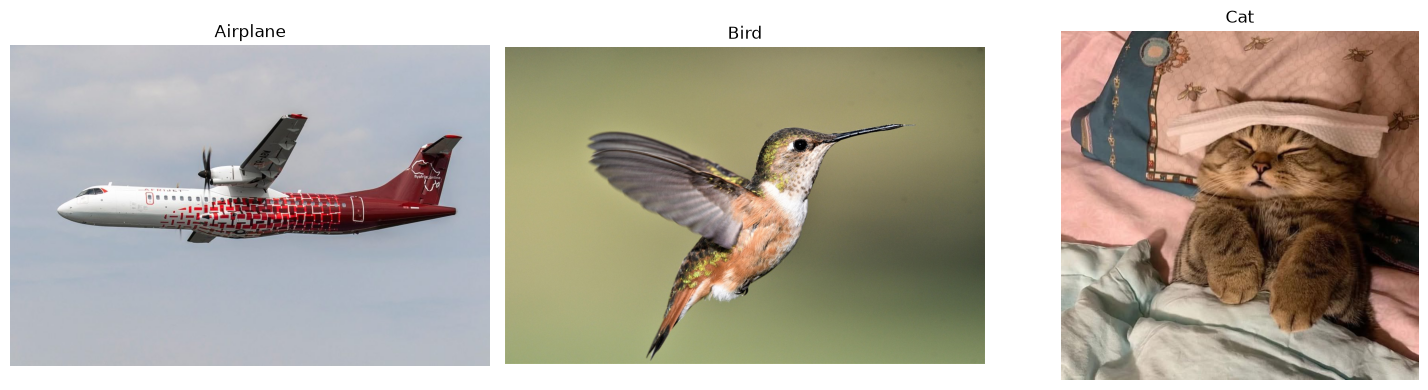

In [7]:
# Displays the loaded test images.
# Shows each image with its filename-based label.
fig, axes = plt.subplots(1,len(images),figsize=(5 * len(images), 4))
if len(images) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(image_names[i])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Processes the loaded images with the ViT image processor.
# Creates the pixel tensor used as model input.
inputs = image_processor(images=images,return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)
print("Pixel values shape:")
print(pixel_values.shape)

Pixel values shape:
torch.Size([3, 3, 224, 224])


In [9]:
# Runs ViT inference on the processed images.
# Stores the output logits for classification.
with torch.inference_mode():
    outputs = model(pixel_values=pixel_values)
logits = outputs.logits
print("Logits shape:")
print(logits.shape)

Logits shape:
torch.Size([3, 1000])


In [10]:
# Converts logits into probabilities.
# Extracts the top-1 predicted class index and confidence.
probabilities = torch.softmax(logits, dim=1)
top1_probabilities, top1_indices = torch.max(probabilities,dim=1)
print("Top-1 probabilities:")
print(top1_probabilities)
print("\nTop-1 class indices:")
print(top1_indices)

Top-1 probabilities:
tensor([0.9184, 0.9589, 0.3534], device='cuda:0')

Top-1 class indices:
tensor([404,  94, 281], device='cuda:0')


In [11]:
# Builds a table of image-classification results.
# Maps predicted class IDs to ImageNet labels.
results = []
for i, (class_id, confidence) in enumerate(zip(top1_indices, top1_probabilities)):
    class_id = class_id.item()
    confidence = confidence.item()
    predicted_label = model.config.id2label[class_id]
    results.append({
        "Image": image_paths[i].name,
        "Expected Object": image_names[i],
        "Predicted Class ID": class_id,
        "Top-1 ImageNet Prediction": predicted_label,
        "Confidence (%)": round(confidence * 100, 2)})
    
results_df = pd.DataFrame(results)
results_df

,Image,Expected Object,Predicted Class ID,Top-1 ImageNet Prediction,Confidence (%)
0,airplane.jpeg,Airplane,404,airliner,91.84
1,bird.jpg,Bird,94,hummingbird,95.89
2,cat.jpg,Cat,281,"tabby, tabby cat",35.34


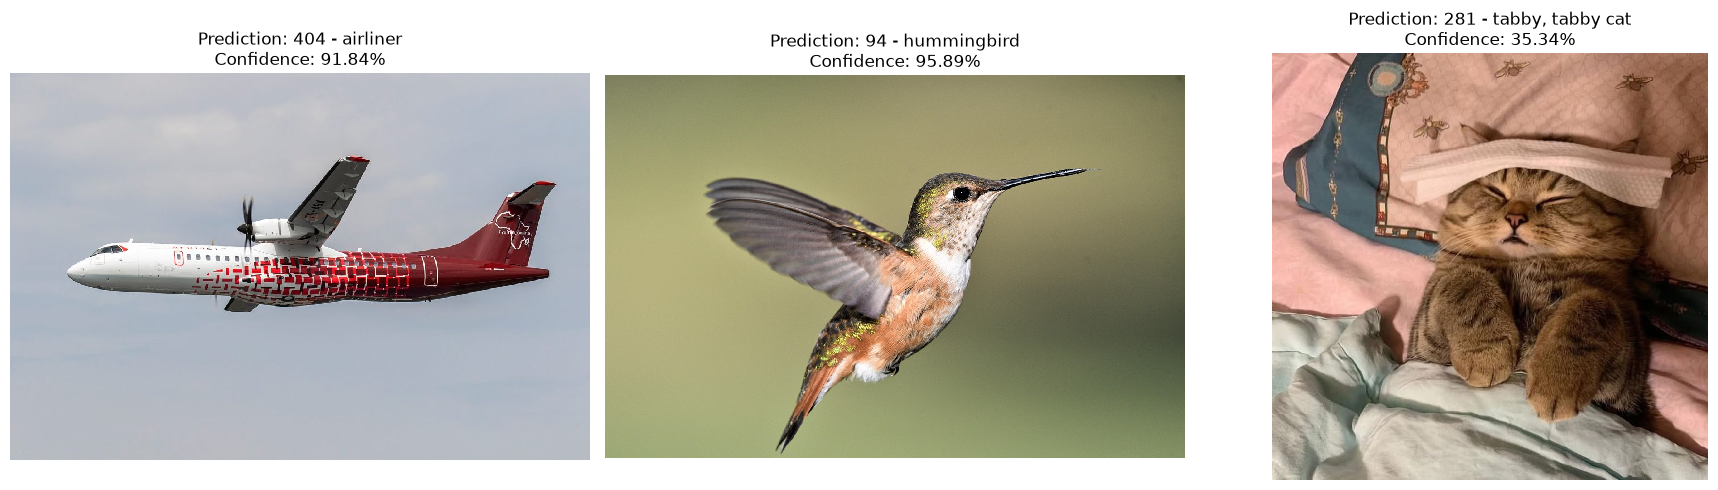

In [12]:
# Visualizes each image with its top-1 prediction.
# Shows predicted labels and confidence scores above the images.
fig, axes = plt.subplots(1,len(images),figsize=(6 * len(images), 5))
if len(images) == 1:
    axes = [axes]
for i, (ax, image) in enumerate(zip(axes, images)):
    class_id = top1_indices[i].item()
    confidence = top1_probabilities[i].item() * 100
    prediction = model.config.id2label[class_id]
    ax.imshow(image, interpolation="nearest")
    ax.set_title(
        f"Prediction: {class_id} - {prediction}\n"
        f"Confidence: {confidence:.2f}%")
    ax.axis("off")
    
plt.tight_layout()
plt.show()

## 2) Visualizing Patch Attention:

In [13]:
# Reloads the same ViT model using eager attention.
# Enables access to attention matrices for visualization.
model_name = "WinKawaks/vit-small-patch16-224"
image_processor = AutoImageProcessor.from_pretrained(model_name,cache_dir=str(download_dir))
model = ViTForImageClassification.from_pretrained(model_name,cache_dir=str(download_dir),attn_implementation="eager")
model = model.to(device)
model.eval()
print("Model loaded for attention visualization.")
print("Attention implementation:", model.config._attn_implementation)

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 6648.02it/s]

Model loaded for attention visualization.
Attention implementation: eager


In [14]:
# Processes the same test images for attention analysis.
# Creates the pixel tensor used by the attention-enabled model.
inputs = image_processor(images=images,return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)
print("Number of images:", len(images))
print("Pixel values shape:", pixel_values.shape)

Number of images: 3
Pixel values shape: torch.Size([3, 3, 224, 224])


In [15]:
# Runs inference while requesting attention outputs.
# Stores model outputs containing attention matrices.
with torch.inference_mode():
    outputs = model(pixel_values=pixel_values,output_attentions=True)
print("Inference completed.")

Inference completed.


In [16]:
# Inspects attention tensors from all transformer layers.
# Prints each layer attention shape.
attentions = outputs.attentions
print("Number of Transformer layers:", len(attentions))
for layer_number, attention in enumerate(attentions):
    print(f"Layer {layer_number + 1}: "
        f"{attention.shape}")

Number of Transformer layers: 12
Layer 1: torch.Size([3, 6, 197, 197])
Layer 2: torch.Size([3, 6, 197, 197])
Layer 3: torch.Size([3, 6, 197, 197])
Layer 4: torch.Size([3, 6, 197, 197])
Layer 5: torch.Size([3, 6, 197, 197])
Layer 6: torch.Size([3, 6, 197, 197])
Layer 7: torch.Size([3, 6, 197, 197])
Layer 8: torch.Size([3, 6, 197, 197])
Layer 9: torch.Size([3, 6, 197, 197])
Layer 10: torch.Size([3, 6, 197, 197])
Layer 11: torch.Size([3, 6, 197, 197])
Layer 12: torch.Size([3, 6, 197, 197])


In [17]:
# Selects the final transformer-layer attention tensor.
# Prints its shape before extracting CLS attention.
final_attention = attentions[-1]
print("Final attention shape:")
print(final_attention.shape)

Final attention shape:
torch.Size([3, 6, 197, 197])


In [18]:
# Extracts CLS-token attention to image patches.
# Drops the CLS-to-CLS column and keeps patch attention only.
cls_to_patches = final_attention[:, :, 0, 1:]
print("CLS-to-patch attention shape:")
print(cls_to_patches.shape)

CLS-to-patch attention shape:
torch.Size([3, 6, 196])


In [19]:
# Averages CLS-to-patch attention over attention heads.
# Creates one attention vector per image.
cls_attention_mean = cls_to_patches.mean(dim=1)
print("Shape after averaging heads:")
print(cls_attention_mean.shape)

Shape after averaging heads:
torch.Size([3, 196])


In [20]:
# Converts patch attention vectors into square grids.
# Checks the patch count and reshapes attention maps.
num_patches = cls_attention_mean.shape[-1]
grid_size = int(math.sqrt(num_patches))
print("Number of patches:", num_patches)
print("Patch grid:", grid_size, "x", grid_size)
assert grid_size * grid_size == num_patches
attention_maps = cls_attention_mean.reshape(len(images),grid_size,grid_size)
print("Attention maps shape:")
print(attention_maps.shape)

Number of patches: 196
Patch grid: 14 x 14
Attention maps shape:
torch.Size([3, 14, 14])


In [21]:
# Normalizes each attention map between zero and one.
# Stacks normalized maps for visualization.
normalized_attention_maps = []
for attention_map in attention_maps:
    min_value = attention_map.min()
    max_value = attention_map.max()
    normalized_map = ((attention_map - min_value) / (max_value - min_value + 1e-8))
    normalized_attention_maps.append(normalized_map)

normalized_attention_maps = torch.stack(normalized_attention_maps)
print("Normalized attention map shape:")
print(normalized_attention_maps.shape)
print("Minimum:", normalized_attention_maps.min().item())
print("Maximum:", normalized_attention_maps.max().item())

Normalized attention map shape:
torch.Size([3, 14, 14])
Minimum: 0.0
Maximum: 0.9999999403953552


In [22]:
# Upsamples patch-level attention to image resolution.
# Creates full-size attention maps for overlays.
attention_for_resize = normalized_attention_maps.unsqueeze(1)
upsampled_attention = F.interpolate(attention_for_resize,size=(224, 224),mode="bilinear",align_corners=False)
upsampled_attention = upsampled_attention.squeeze(1)
print("Upsampled attention shape:")
print(upsampled_attention.shape)

Upsampled attention shape:
torch.Size([3, 224, 224])


In [23]:
# Computes predictions from the attention-enabled model.
# Stores predicted labels and confidence values for display.
probabilities = torch.softmax(outputs.logits,dim=1)
top1_probabilities, top1_indices = probabilities.max(dim=1)
predicted_labels = []

for class_id in top1_indices:
    class_id = class_id.item()
    predicted_label = model.config.id2label[class_id]
    predicted_labels.append(predicted_label)

for i in range(len(images)):
    print(
        f"{image_paths[i].name}: "
        f"{predicted_labels[i]} "
        f"({top1_probabilities[i].item() * 100:.2f}%)")

airplane.jpeg: airliner (91.84%)
bird.jpg: hummingbird (95.89%)
cat.jpg: tabby, tabby cat (35.34%)


In [24]:
# Resizes original images for attention visualization.
# Prepares display images at the ViT input resolution.
display_images = [
    image.resize((224, 224))
    for image in images]
print("Images prepared for visualization.")

Images prepared for visualization.


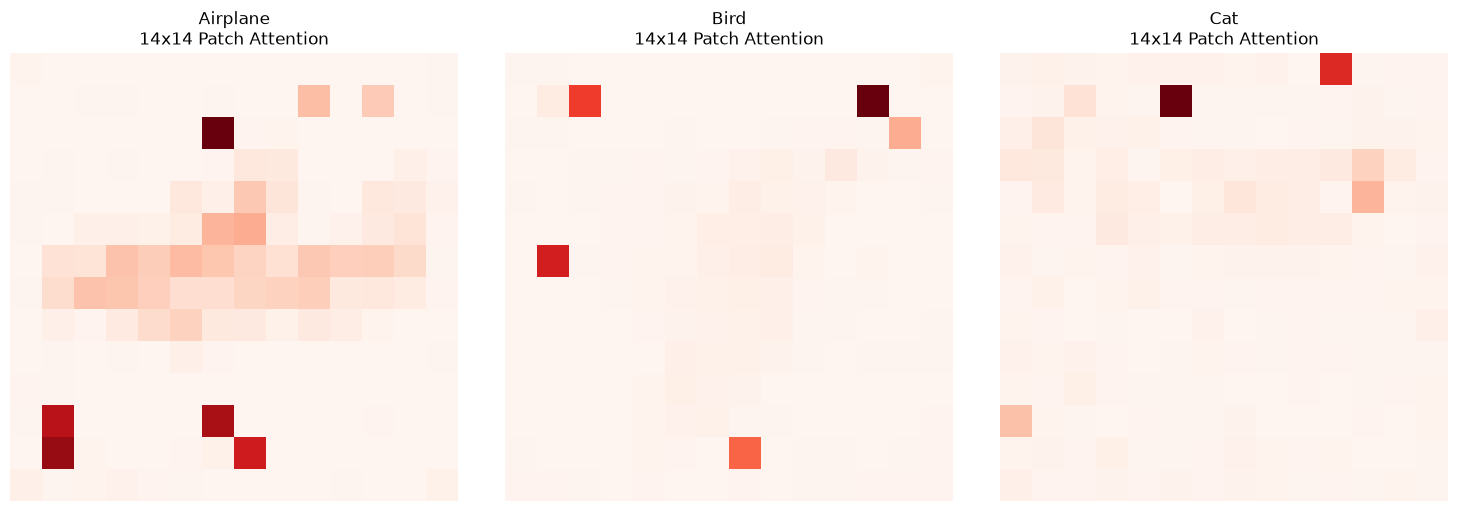

In [25]:
# Plots the raw 14-by-14 patch attention maps.
# Shows final-layer CLS attention for each image.
fig, axes = plt.subplots(1,len(images),figsize=(5 * len(images), 5))
if len(images) == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    heatmap = normalized_attention_maps[i].detach().cpu().numpy()
    ax.imshow(heatmap,cmap="Reds")
    ax.set_title(
        f"{image_names[i]}\n"
        f"14x14 Patch Attention")
    ax.axis("off")
    
plt.tight_layout()
plt.show()

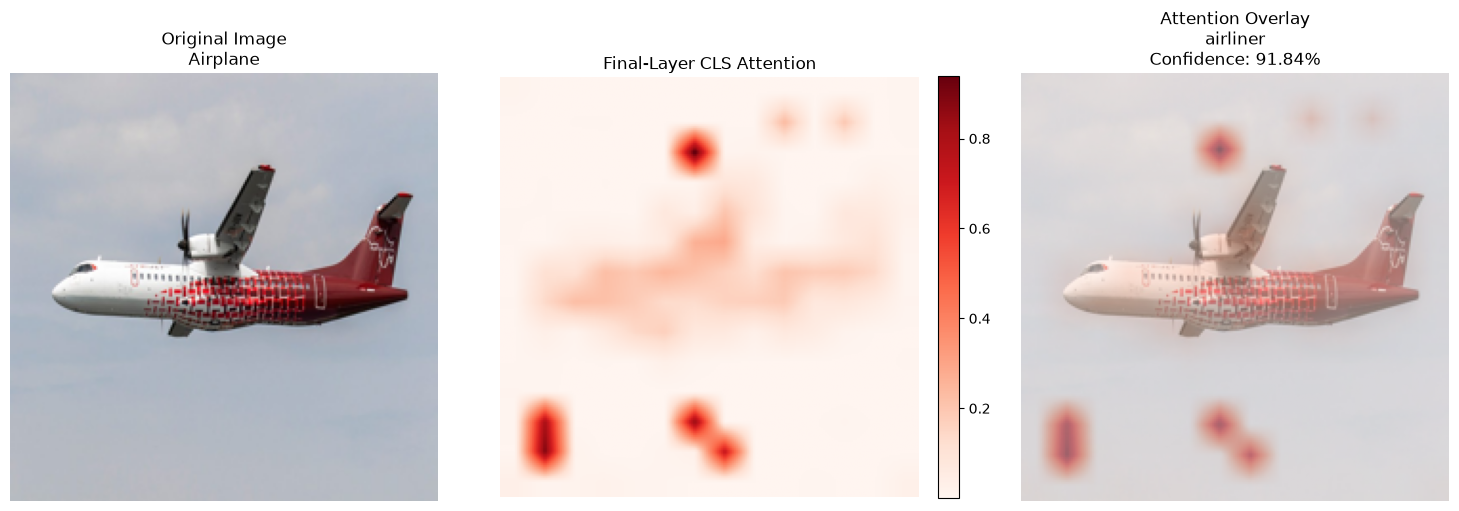

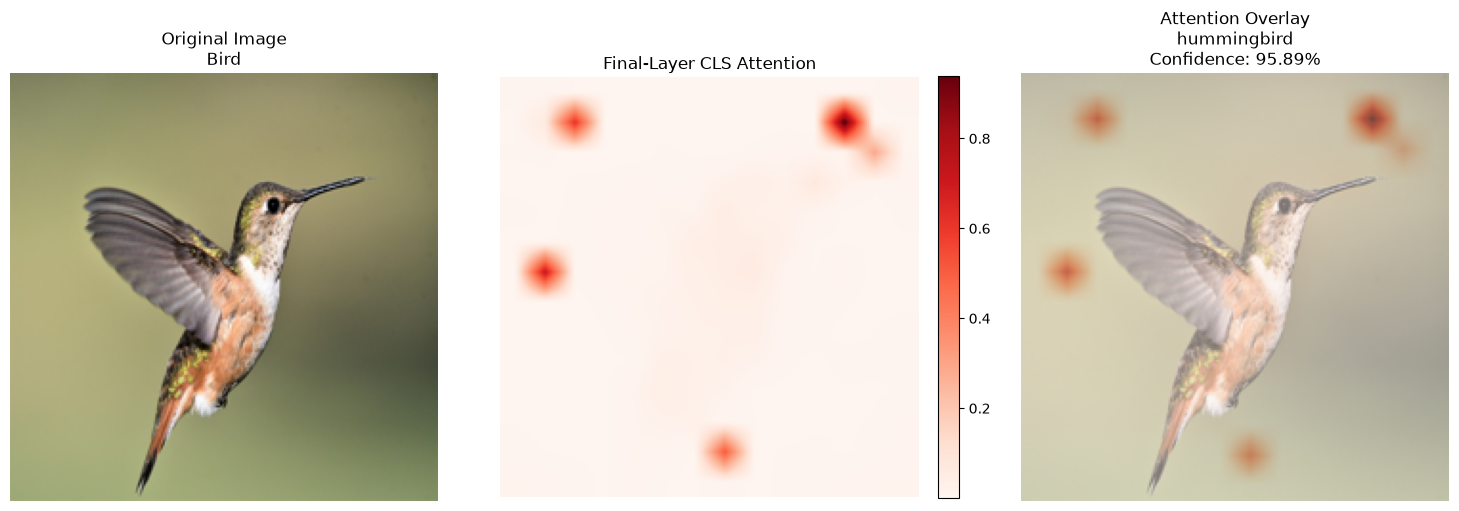

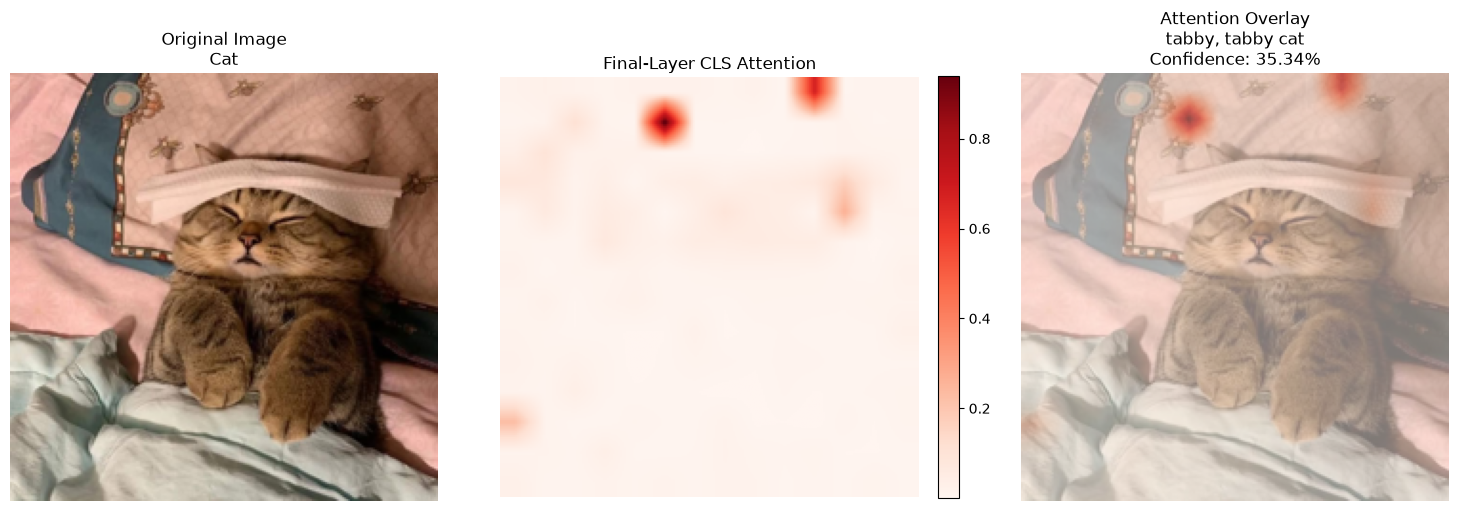

In [26]:
# Displays original images, attention heatmaps, and overlays.
# Uses final-layer CLS attention to highlight attended regions.
for i in range(len(images)):
    heatmap = (upsampled_attention[i].detach().cpu().numpy())
    prediction = predicted_labels[i]
    confidence = top1_probabilities[i].item() * 100
    fig, axes = plt.subplots(1,3,figsize=(15, 5))
    axes[0].imshow(display_images[i])
    axes[0].set_title(
        f"Original Image\n"
        f"{image_names[i]}")
    axes[0].axis("off")
    heatmap_plot = axes[1].imshow(heatmap,cmap="Reds")
    axes[1].set_title("Final-Layer CLS Attention")
    axes[1].axis("off")
    fig.colorbar(heatmap_plot,ax=axes[1],fraction=0.046,pad=0.04)
    axes[2].imshow(display_images[i])
    axes[2].imshow(heatmap,cmap="Reds",alpha=0.5)
    axes[2].set_title(
        f"Attention Overlay\n"
        f"{prediction}\n"
        f"Confidence: {confidence:.2f}%")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

In [27]:
# Prints a compact ViT attention summary.
# Reports patch, attention, and upsampled-map shapes.
print("----- ViT Attention Summary -----")
print(f"Input image size: {model.config.image_size} x {model.config.image_size}")
print(f"Patch size: {model.config.patch_size} x {model.config.patch_size}")
print(f"Number of patches: {num_patches}")
print(f"Number of attention heads: {model.config.num_attention_heads}")
print(f"Number of Transformer layers: {model.config.num_hidden_layers}")
print(f"Final attention matrix: {tuple(final_attention.shape)}")
print(f"CLS-to-patches: {tuple(cls_to_patches.shape)}")
print(f"After averaging heads: {tuple(cls_attention_mean.shape)}")
print(f"Patch attention map: {tuple(attention_maps.shape)}")
print(f"Upsampled attention map: {tuple(upsampled_attention.shape)}")

----- ViT Attention Summary -----
Input image size: 224 x 224
Patch size: 16 x 16
Number of patches: 196
Number of attention heads: 6
Number of Transformer layers: 12
Final attention matrix: (3, 6, 197, 197)
CLS-to-patches: (3, 6, 196)
After averaging heads: (3, 196)
Patch attention map: (3, 14, 14)
Upsampled attention map: (3, 224, 224)


## 3) Analyze the Attention Map:

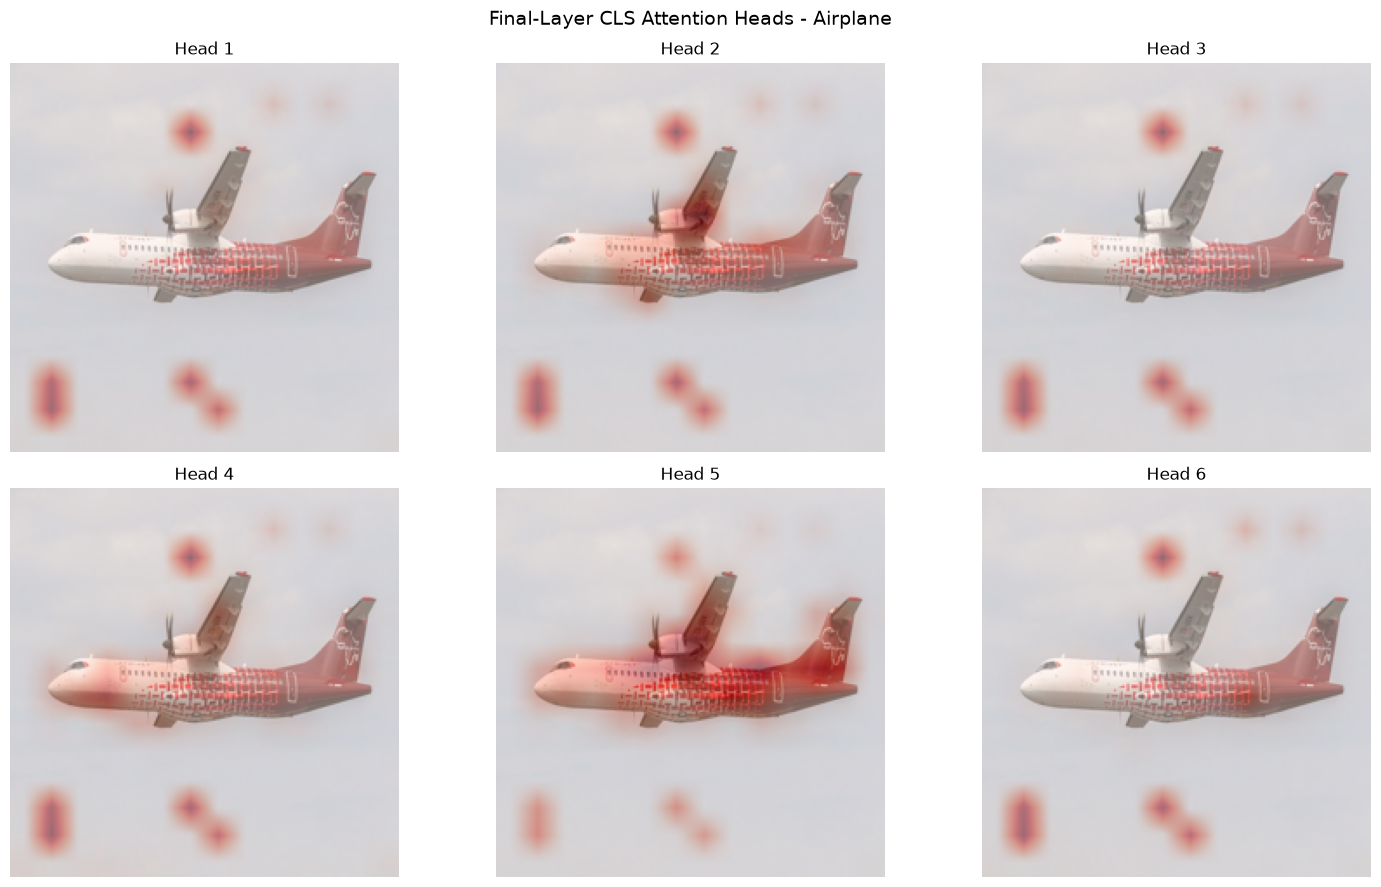

In [28]:
# Visualizes every final-layer attention head for the airplane image.
# Compares whether different heads focus on object, context, or background.
attention_image_index = 0
attention_figure_dir = Path("figures")
attention_figure_dir.mkdir(parents=True,exist_ok=True)
head_cls_attention = final_attention[attention_image_index,:,0,1:].detach()
head_attention_maps = head_cls_attention.reshape(model.config.num_attention_heads,grid_size,grid_size)
normalized_head_maps = []
head_summary = []

for head_number, head_map in enumerate(head_attention_maps):
    min_value = head_map.min()
    max_value = head_map.max()
    normalized_map = ((head_map - min_value) / (max_value - min_value + 1e-8))
    normalized_head_maps.append(normalized_map)
    sorted_attention = torch.sort(head_map.flatten(),descending=True).values
    head_summary.append({
        "Attention Head": head_number + 1,
        "Maximum Attention": round(head_map.max().item(),4),
        "Top-10 Patch Attention": round(sorted_attention[:10].sum().item(),4)})

normalized_head_maps = torch.stack(normalized_head_maps)
head_attention_for_resize = normalized_head_maps.unsqueeze(1)
upsampled_head_attention = F.interpolate(head_attention_for_resize,size=(224,224),mode="bilinear",align_corners=False).squeeze(1)
fig, axes = plt.subplots(2,3,figsize=(15, 9))

for head_number, ax in enumerate(axes.flat):
    heatmap = upsampled_head_attention[head_number].detach().cpu().numpy()
    ax.imshow(display_images[attention_image_index])
    ax.imshow(heatmap,cmap="Reds",alpha=0.45)
    ax.set_title(f"Head {head_number + 1}")
    ax.axis("off")

plt.suptitle(f"Final-Layer CLS Attention Heads - Airplane",fontsize=14)
plt.tight_layout()
plt.show()

## 4) Patch-Masking Experiment:

In [29]:
# Computes patch-grid settings for masking.
# Uses the model image size and patch size to count patches.
patch_size = model.config.patch_size
image_size = model.config.image_size
grid_size = image_size // patch_size
total_patches = grid_size * grid_size
print("Image size:", image_size, "x", image_size)
print("Patch size:", patch_size, "x", patch_size)
print("Patch grid:", grid_size, "x", grid_size)
print("Total patches:", total_patches)

Image size: 224 x 224
Patch size: 16 x 16
Patch grid: 14 x 14
Total patches: 196


In [30]:
# Defines a helper for ViT image prediction.
# Returns class IDs, labels, and confidence scores.
def predict_images(input_tensor):
    with torch.inference_mode():
        outputs = model(pixel_values=input_tensor)
    probabilities = torch.softmax(outputs.logits, dim=1)
    confidence, class_ids = probabilities.max(dim=1)
    labels = [
        model.config.id2label[class_id.item()]
        for class_id in class_ids]
    return class_ids, labels, confidence

In [31]:
# Computes predictions for the unmasked images.
# Prints original labels and confidence values.
original_ids, original_labels, original_confidence = predict_images(pixel_values)
print("Original predictions:\n")
for i in range(len(images)):
    print(
        f"{image_paths[i].name}: "
        f"{original_labels[i]} "
        f"({original_confidence[i].item() * 100:.2f}%)")

Original predictions:

airplane.jpeg: airliner (91.84%)
bird.jpg: hummingbird (95.89%)
cat.jpg: tabby, tabby cat (35.34%)


In [32]:
# Defines random patch masking for ViT inputs.
# Masks a selected fraction of patches in normalized pixel space.
def random_patch_mask(pixel_values, mask_fraction, seed=42):
    masked_images = pixel_values.clone()
    batch_size = masked_images.shape[0]
    masks = torch.zeros(batch_size,grid_size,grid_size,dtype=torch.bool)
    num_to_mask = int(total_patches * mask_fraction)

    for image_index in range(batch_size):
        generator = torch.Generator()
        generator.manual_seed(seed + image_index)
        selected = torch.randperm(total_patches,generator=generator)[:num_to_mask]

        for patch_index in selected:
            row = patch_index.item() // grid_size
            col = patch_index.item() % grid_size
            masks[image_index, row, col] = True
            y1 = row * patch_size
            y2 = y1 + patch_size
            x1 = col * patch_size
            x2 = x1 + patch_size
            masked_images[image_index,:,y1:y2,x1:x2] = 0.0

    return masked_images, masks

In [33]:
# Defines center patch masking for ViT inputs.
# Masks patches closest to the image center first.
def center_patch_mask(pixel_values, mask_fraction):
    masked_images = pixel_values.clone()
    batch_size = masked_images.shape[0]
    masks = torch.zeros(batch_size,grid_size,grid_size,dtype=torch.bool)
    num_to_mask = int(total_patches * mask_fraction)
    center = (grid_size - 1) / 2
    patch_distances = []
    for row in range(grid_size):
        for col in range(grid_size):
            distance = ((row - center) ** 2 + (col - center) ** 2)
            patch_index = row * grid_size + col
            patch_distances.append((distance, patch_index))
    patch_distances.sort(key=lambda x: x[0])
    selected = [patch_index
        for _, patch_index
        in patch_distances[:num_to_mask]]

    for image_index in range(batch_size):
        for patch_index in selected:
            row = patch_index // grid_size
            col = patch_index % grid_size
            masks[image_index, row, col] = True
            y1 = row * patch_size
            y2 = y1 + patch_size
            x1 = col * patch_size
            x2 = x1 + patch_size
            masked_images[image_index,:,y1:y2,x1:x2] = 0.0
    return masked_images, masks

In [34]:
# Creates random and center-masked image tensors.
# Uses a fixed mask fraction for the first masking comparison.
mask_fraction = 0.50
random_masked, random_masks = random_patch_mask(pixel_values,mask_fraction=mask_fraction,seed=42)
center_masked, center_masks = center_patch_mask(pixel_values,mask_fraction=mask_fraction)
print(f"Masking {mask_fraction * 100:.0f}% "
    f"of the {total_patches} patches")
print("Number of masked patches:", int(total_patches * mask_fraction))

Masking 50% of the 196 patches
Number of masked patches: 98


In [35]:
# Runs predictions on the random and center-masked images.
# Stores labels and confidence scores for both masking methods.
random_ids, random_labels, random_confidence = predict_images(random_masked)
center_ids, center_labels, center_confidence = predict_images(center_masked)

In [36]:
# Prints original versus masked predictions.
# Compares confidence under random and center masking.
for i in range(len(images)):
    print("\n--------------------------------")
    print(f"Image {i+1} - {image_names[i]}")
    print("Original:",
        original_labels[i],
        f"({original_confidence[i].item() * 100:.2f}%)")
    print("Random mask:",
        random_labels[i],
        f"({random_confidence[i].item() * 100:.2f}%)")
    print("Center mask:",
        center_labels[i],
        f"({center_confidence[i].item() * 100:.2f}%)")


--------------------------------
Image 1 - Airplane
Original: airliner (91.84%)
Random mask: airliner (96.46%)
Center mask: parachute, chute (83.58%)

--------------------------------
Image 2 - Bird
Original: hummingbird (95.89%)
Random mask: hummingbird (99.59%)
Center mask: bee eater (52.95%)

--------------------------------
Image 3 - Cat
Original: tabby, tabby cat (35.34%)
Random mask: quilt, comforter, comfort, puff (8.40%)
Center mask: quilt, comforter, comfort, puff (17.41%)


In [37]:
# Defines a helper to convert tensors back to images.
# Reverses ViT normalization for display.
def tensor_to_image(tensor):
    image = tensor.detach().cpu().clone()
    mean = torch.tensor(image_processor.image_mean).view(3, 1, 1)
    std = torch.tensor(image_processor.image_std).view(3, 1, 1)
    image = image * std + mean
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0).numpy()
    return image

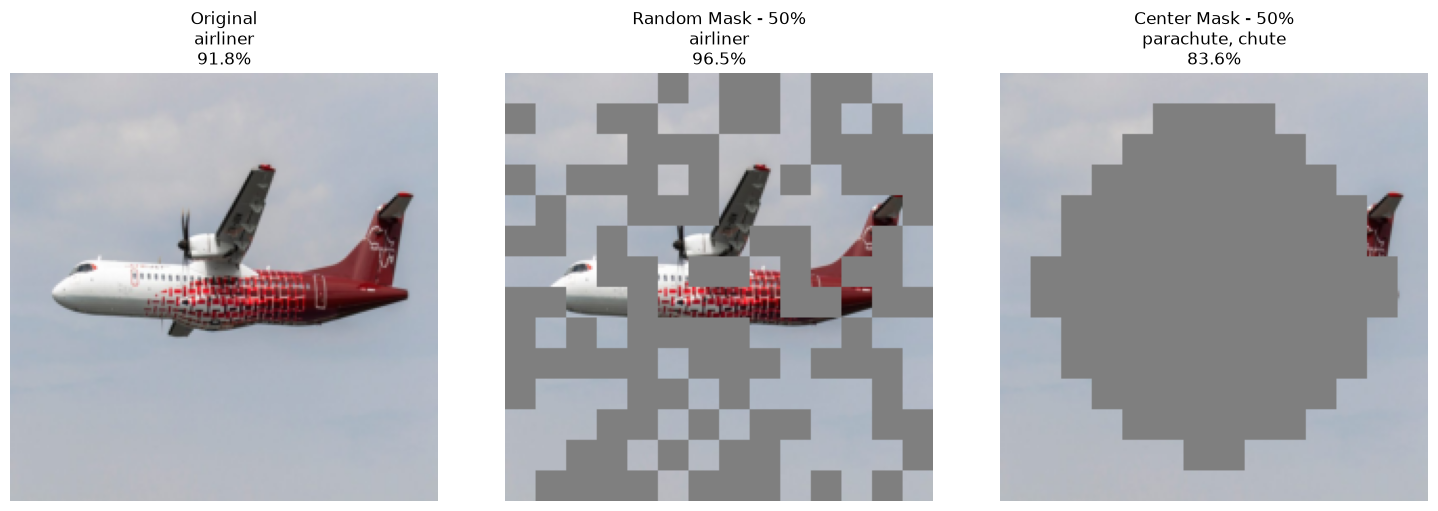

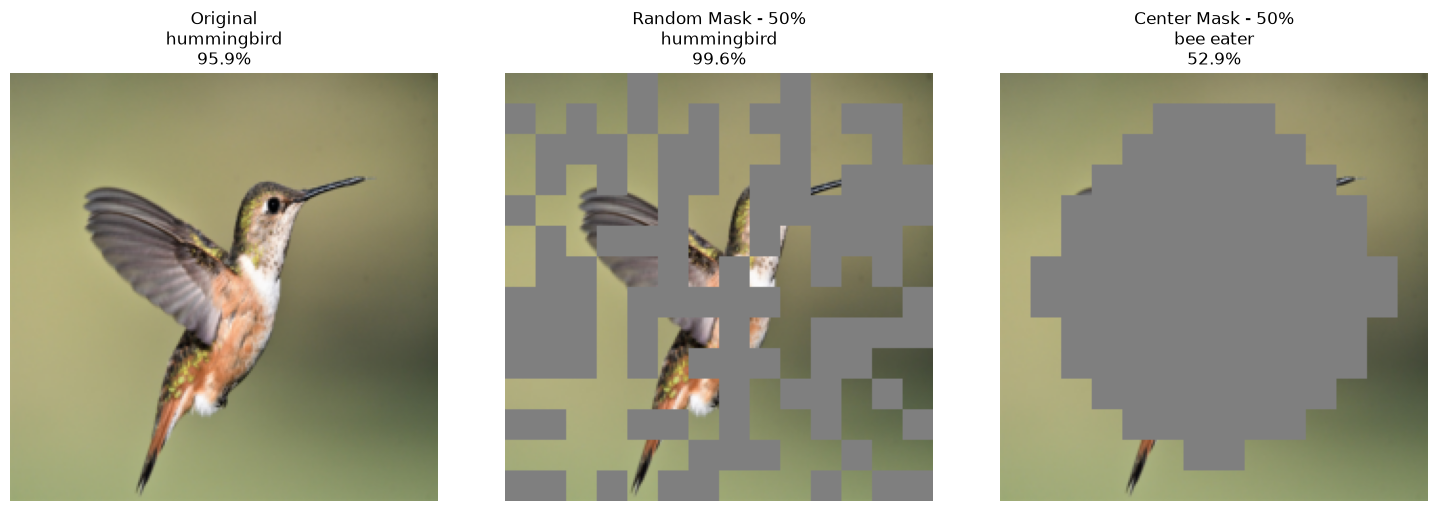

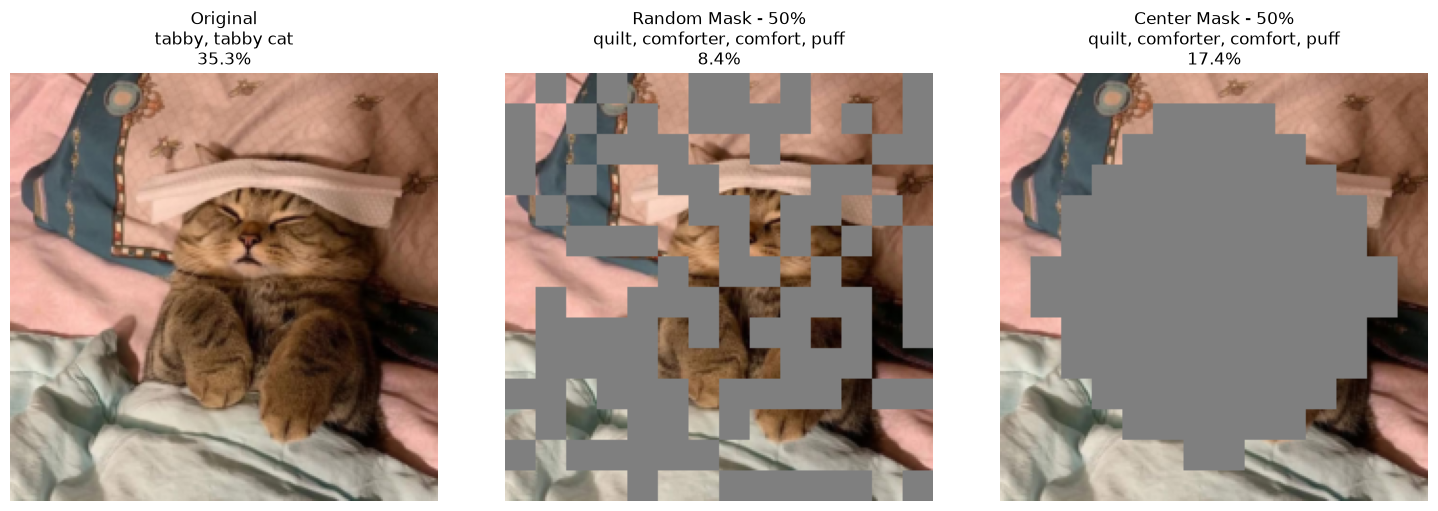

In [38]:
# Visualizes original, random-masked, and center-masked images.
# Shows how masking changes predictions and confidence.
for i in range(len(images)):
    fig, axes = plt.subplots(1,3,figsize=(15, 5))
    axes[0].imshow(tensor_to_image(pixel_values[i]))
    axes[0].set_title(f"Original\n"
        f"{original_labels[i]}\n"
        f"{original_confidence[i].item()*100:.1f}%")
    axes[0].axis("off")
    axes[1].imshow(tensor_to_image(random_masked[i]))
    axes[1].set_title(f"Random Mask - 50%\n"
        f"{random_labels[i]}\n"
        f"{random_confidence[i].item()*100:.1f}%")
    axes[1].axis("off")
    axes[2].imshow(tensor_to_image(center_masked[i]))
    axes[2].set_title(f"Center Mask - 50%\n"
        f"{center_labels[i]}\n"
        f"{center_confidence[i].item()*100:.1f}%")
    axes[2].axis("off")
    plt.tight_layout()
    plt.show()

In [39]:
# Runs masking experiments over several mask fractions.
# Stores prediction retention and confidence results.
mask_fractions = [0.00,0.25,0.50,0.75]
experiment_results = []
for fraction in mask_fractions:
    if fraction == 0:
        current_random = pixel_values
        current_center = pixel_values
    else:
        current_random, _ = random_patch_mask(pixel_values,mask_fraction=fraction,seed=42)
        current_center, _ = center_patch_mask(pixel_values,mask_fraction=fraction)

    _, random_labels_now, random_conf_now = predict_images(current_random)
    _, center_labels_now, center_conf_now = predict_images(current_center)

    for i in range(len(images)):
        experiment_results.append({
            "Image": image_paths[i].name,
            "Expected Object": image_names[i],
            "Mask Type": "Random",
            "Mask Fraction": fraction,
            "Masked Patches": int(total_patches * fraction),
            "Original Prediction": original_labels[i],
            "Masked Prediction": random_labels_now[i],
            "Confidence (%)": round(random_conf_now[i].item() * 100,2),
            "Prediction Preserved": (random_labels_now[i] == original_labels[i])})
        experiment_results.append({
            "Image": image_paths[i].name,
            "Expected Object": image_names[i],
            "Mask Type": "Center",
            "Mask Fraction": fraction,
            "Masked Patches": int(total_patches * fraction),
            "Original Prediction": original_labels[i],
            "Masked Prediction": center_labels_now[i],
            "Confidence (%)": round(center_conf_now[i].item() * 100,2),
            "Prediction Preserved": (center_labels_now[i] == original_labels[i])})

In [40]:
# Creates a dataframe from patch-masking results.
# Displays per-image results for every mask setting.
mask_results_df = pd.DataFrame(experiment_results)
mask_results_df

,Image,Expected Object,Mask Type,Mask Fraction,Masked Patches,Original Prediction,Masked Prediction,Confidence (%),Prediction Preserved
0,airplane.jpeg,Airplane,Random,0.00,0,airliner,airliner,91.84,True
1,airplane.jpeg,Airplane,Center,0.00,0,airliner,airliner,91.84,True
2,bird.jpg,Bird,Random,0.00,0,hummingbird,hummingbird,95.89,True
3,bird.jpg,Bird,Center,0.00,0,hummingbird,hummingbird,95.89,True
4,cat.jpg,Cat,Random,0.00,0,"tabby, tabby cat","tabby, tabby cat",35.34,True
5,cat.jpg,Cat,Center,0.00,0,"tabby, tabby cat","tabby, tabby cat",35.34,True
6,airplane.jpeg,Airplane,Random,0.25,49,airliner,airliner,96.42,True
7,airplane.jpeg,Airplane,Center,0.25,49,airliner,"airship, dirigible",29.62,False
8,bird.jpg,Bird,Random,0.25,49,hummingbird,hummingbird,99.54,True
9,bird.jpg,Bird,Center,0.25,49,hummingbird,hummingbird,97.40,True


In [41]:
# Summarizes prediction retention by mask type and fraction.
# Reports how often masked predictions match the original.
robustness_summary = (mask_results_df.groupby(["Mask Type", "Mask Fraction"])["Prediction Preserved"].mean().reset_index())
robustness_summary["Prediction Retention (%)"] = (robustness_summary["Prediction Preserved"] * 100)
robustness_summary = robustness_summary.drop(columns=["Prediction Preserved"])
robustness_summary

,Mask Type,Mask Fraction,Prediction Retention (%)
0,Center,0.00,100.000000
1,Center,0.25,33.333333
2,Center,0.50,0.000000
3,Center,0.75,33.333333
4,Random,0.00,100.000000
5,Random,0.25,66.666667
6,Random,0.50,66.666667
7,Random,0.75,66.666667


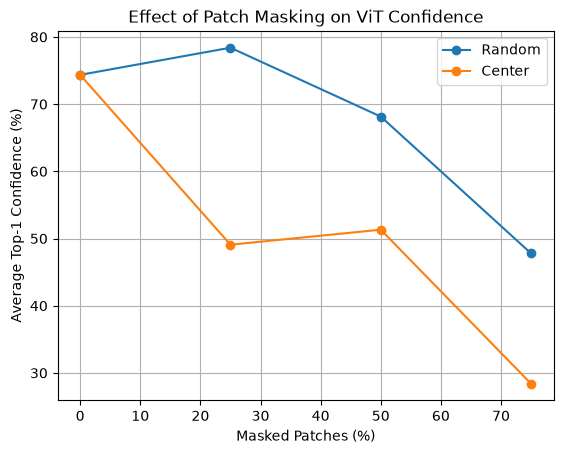

In [42]:
# Plots average confidence under increasing masking.
# Compares random masking against center masking.
confidence_summary = (mask_results_df.groupby(["Mask Type", "Mask Fraction"])["Confidence (%)"].mean().reset_index())

for mask_type in ["Random", "Center"]:
    subset = confidence_summary[confidence_summary["Mask Type"] == mask_type]
    plt.plot(subset["Mask Fraction"] * 100,subset["Confidence (%)"],marker="o",label=mask_type)

plt.xlabel("Masked Patches (%)")
plt.ylabel("Average Top-1 Confidence (%)")
plt.title("Effect of Patch Masking on ViT Confidence")
plt.legend()
plt.grid(True)
plt.show()

## 5) CLS Token vs. Mean-Pooled Patch Tokens:

In [43]:
# Builds a small CIFAR-10 subset for linear probes.
# Creates ViT-ready DataLoaders for train and test samples.
probe_train_samples, probe_test_samples, probe_batch_size = 1000, 300, 32
probe_train_full = vision_datasets.CIFAR10(root="../Data", train=True, download=True)
probe_test_full = vision_datasets.CIFAR10(root="../Data", train=False, download=True)
generator = torch.Generator().manual_seed(42)
train_indices = torch.randperm(len(probe_train_full), generator=generator)[:probe_train_samples]
test_indices = torch.randperm(len(probe_test_full), generator=generator)[:probe_test_samples]
probe_train_dataset = Subset(probe_train_full, train_indices.tolist())
probe_test_dataset = Subset(probe_test_full, test_indices.tolist())

def probe_collate_fn(batch):
    batch_images, batch_labels = zip(*batch)
    encoded = image_processor(images=list(batch_images), return_tensors="pt")
    labels = torch.tensor(batch_labels, dtype=torch.long)
    return encoded["pixel_values"], labels

probe_train_image_loader = DataLoader(probe_train_dataset, batch_size=probe_batch_size, shuffle=False, num_workers=0, collate_fn=probe_collate_fn)
probe_test_image_loader = DataLoader(probe_test_dataset, batch_size=probe_batch_size, shuffle=False, num_workers=0, collate_fn=probe_collate_fn)
print("Linear-probe train images:", len(probe_train_dataset))
print("Linear-probe test images:", len(probe_test_dataset))
print("CIFAR-10 classes:", probe_train_full.classes)

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Linear-probe train images: 1000
Linear-probe test images: 300
CIFAR-10 classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [44]:
# Defines feature extraction from the frozen ViT.
# Returns CLS-token and mean-pooled patch representations.
def extract_vit_features(data_loader):
    model.eval()

    for parameter in model.parameters():
        parameter.requires_grad = False

    cls_features = []
    mean_patch_features = []
    all_labels = []
    with torch.inference_mode():
        for pixel_batch, label_batch in data_loader:
            pixel_batch = pixel_batch.to(device)
            outputs = model(pixel_values=pixel_batch,output_hidden_states=True)
            final_hidden_state = outputs.hidden_states[-1]
            cls_batch = final_hidden_state[:, 0, :]
            patch_batch = final_hidden_state[:, 1:, :]
            mean_patch_batch = patch_batch.mean(dim=1)
            cls_features.append(cls_batch.cpu())
            mean_patch_features.append(mean_patch_batch.cpu())
            all_labels.append(label_batch.cpu())

    cls_features = torch.cat(cls_features, dim=0)
    mean_patch_features = torch.cat(mean_patch_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return cls_features, mean_patch_features, all_labels

In [45]:
# Extracts train and test features for both representations.
# Prints feature and label tensor shapes.
cls_train_features, mean_train_features, probe_train_labels = extract_vit_features(probe_train_image_loader)
cls_test_features, mean_test_features, probe_test_labels = extract_vit_features(probe_test_image_loader)
print("CLS train features:", cls_train_features.shape)
print("Mean-pooled train features:", mean_train_features.shape)
print("Train labels:", probe_train_labels.shape)
print("CLS test features:", cls_test_features.shape)
print("Mean-pooled test features:", mean_test_features.shape)
print("Test labels:", probe_test_labels.shape)

CLS train features: torch.Size([1000, 384])
Mean-pooled train features: torch.Size([1000, 384])
Train labels: torch.Size([1000])
CLS test features: torch.Size([300, 384])
Mean-pooled test features: torch.Size([300, 384])
Test labels: torch.Size([300])


In [46]:
# Defines a DataLoader helper for extracted features.
# Wraps feature tensors and labels into mini-batches.
def make_feature_loader(features, labels, shuffle):
    dataset = TensorDataset(features, labels)
    return DataLoader(dataset,batch_size=64,shuffle=shuffle,num_workers=0)

In [47]:
# Defines evaluation for a linear probe.
# Computes accuracy over a feature DataLoader.
def evaluate_probe(linear_probe, data_loader):
    linear_probe.eval()
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = linear_probe(features)
            predictions = logits.argmax(dim=1)
            total_correct += (predictions == labels).sum().item()
            total_examples += labels.size(0)
            
    return total_correct / total_examples

In [48]:
# Defines training for a linear probe classifier.
# Tracks train and test accuracy across epochs.
def train_linear_probe(train_features,train_labels,test_features,test_labels,probe_name,epochs=20,learning_rate=1e-3):

    torch.manual_seed(42)
    linear_probe = nn.Linear(train_features.shape[1],10).to(device)
    train_loader = make_feature_loader(train_features,train_labels,shuffle=True)
    test_loader = make_feature_loader(test_features,test_labels,shuffle=False)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(linear_probe.parameters(),lr=learning_rate)
    history = {"train_accuracy": [], "test_accuracy": []}

    for epoch in range(epochs):
        linear_probe.train()

        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = linear_probe(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        train_accuracy = evaluate_probe(linear_probe,train_loader)
        test_accuracy = evaluate_probe(linear_probe,test_loader)
        history["train_accuracy"].append(train_accuracy)
        history["test_accuracy"].append(test_accuracy)
        print(f"{probe_name} | Epoch {epoch + 1:02d}/{epochs} | "
            f"Train: {train_accuracy * 100:.2f}% | "
            f"Test: {test_accuracy * 100:.2f}%")

    return linear_probe, history

In [49]:
# Trains CLS-token and mean-pooled patch probes.
# Stores final comparison metrics in a dataframe.
cls_probe, cls_probe_history = train_linear_probe(cls_train_features,probe_train_labels,cls_test_features,probe_test_labels,probe_name="CLS token probe")
mean_probe, mean_probe_history = train_linear_probe(mean_train_features, probe_train_labels, mean_test_features, probe_test_labels, probe_name="Mean-pooled patch probe")

probe_comparison_df = pd.DataFrame([    {
        "Representation": "CLS token",
        "Final Train Accuracy (%)": round(
            cls_probe_history["train_accuracy"][-1] * 100,
            2),
        "Final Test Accuracy (%)": round(
            cls_probe_history["test_accuracy"][-1] * 100,
            2),
    },
    {
        "Representation": "Mean-pooled patches",
        "Final Train Accuracy (%)": round(
            mean_probe_history["train_accuracy"][-1] * 100,
            2),
        "Final Test Accuracy (%)": round(
            mean_probe_history["test_accuracy"][-1] * 100,
            2)
    }
])

CLS token probe | Epoch 01/20 | Train: 81.40% | Test: 81.00%
CLS token probe | Epoch 02/20 | Train: 92.80% | Test: 92.33%
CLS token probe | Epoch 03/20 | Train: 95.50% | Test: 93.33%
CLS token probe | Epoch 04/20 | Train: 97.10% | Test: 94.00%
CLS token probe | Epoch 05/20 | Train: 97.80% | Test: 94.33%
CLS token probe | Epoch 06/20 | Train: 98.50% | Test: 94.33%
CLS token probe | Epoch 07/20 | Train: 98.90% | Test: 94.67%
CLS token probe | Epoch 08/20 | Train: 99.40% | Test: 95.67%
CLS token probe | Epoch 09/20 | Train: 99.70% | Test: 95.33%
CLS token probe | Epoch 10/20 | Train: 99.70% | Test: 95.67%
CLS token probe | Epoch 11/20 | Train: 99.70% | Test: 95.33%
CLS token probe | Epoch 12/20 | Train: 99.80% | Test: 96.00%
CLS token probe | Epoch 13/20 | Train: 99.90% | Test: 96.00%
CLS token probe | Epoch 14/20 | Train: 99.90% | Test: 96.00%
CLS token probe | Epoch 15/20 | Train: 99.90% | Test: 96.00%
CLS token probe | Epoch 16/20 | Train: 99.90% | Test: 96.33%
CLS token probe | Epoch 

,Representation,Final Train Accuracy (%),Final Test Accuracy (%)
0,CLS token,100.0,96.00
1,Mean-pooled patches,99.9,94.33


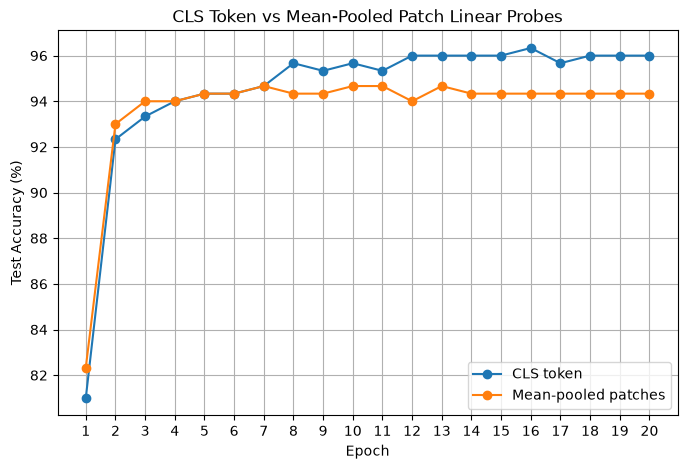

In [50]:
# Displays and plots the linear-probe comparison.
# Compares test accuracy for CLS and mean-pooled features.
display(probe_comparison_df)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cls_probe_history["test_accuracy"]) + 1),[accuracy * 100 for accuracy in cls_probe_history["test_accuracy"]],marker="o",label="CLS token")
plt.plot(range(1, len(mean_probe_history["test_accuracy"]) + 1),[accuracy * 100 for accuracy in mean_probe_history["test_accuracy"]],marker="o",label="Mean-pooled patches")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("CLS Token vs Mean-Pooled Patch Linear Probes")
plt.xticks(range(1, len(cls_probe_history["test_accuracy"]) + 1))
plt.legend()
plt.grid(True)
plt.show()